In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("Advertising.csv", index_col=0)
print("Shape:", df.shape)
print(df.head())

Shape: (200, 4)
      TV  Radio  Newspaper  Sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9


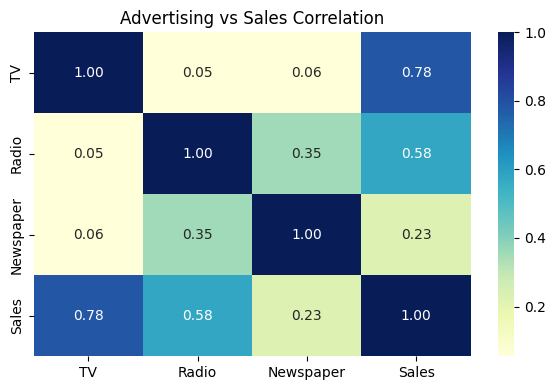

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("Advertising vs Sales Correlation")
plt.tight_layout()
plt.show()

In [9]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"✅ R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"✅ RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat} → {coef:.4f}")

✅ R² Score : 0.8994
✅ RMSE     : 1.7816
  TV → 0.0447
  Radio → 0.1892
  Newspaper → 0.0028


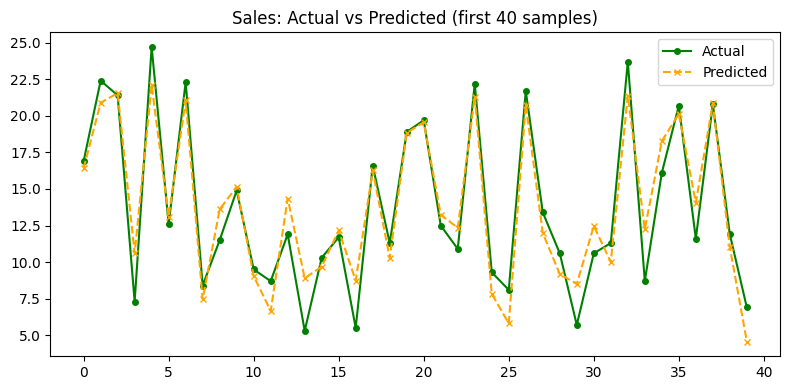

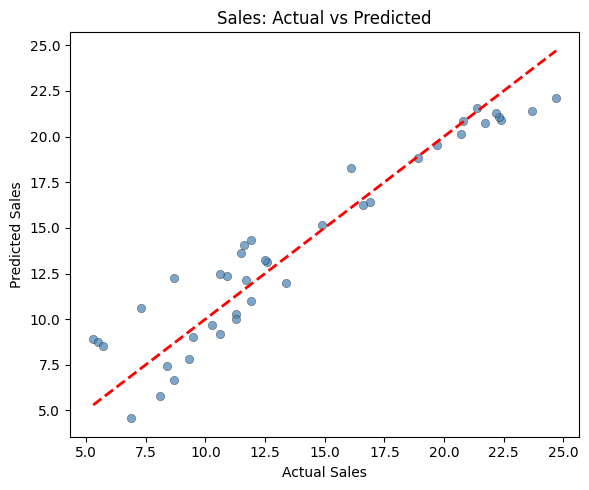

In [10]:
# Actual vs Predicted
plt.figure(figsize=(8,4))
plt.plot(y_test.values[:40], label='Actual', marker='o', markersize=4, color='green')
plt.plot(y_pred[:40], label='Predicted', marker='x', markersize=4, color='orange', linestyle='--')
plt.legend()
plt.title("Sales: Actual vs Predicted (first 40 samples)")
plt.tight_layout()
plt.show()

# Scatter
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Sales: Actual vs Predicted")
plt.tight_layout()
plt.show()